In [20]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
import pandas as pd
import numpy as np

np.random.seed(42)

In [22]:
n = 1000

education_levels = ["High School", "Bachelors", "Masters", "PhD"]
visa_types = ["Student", "Work", "Tourist"]
countries = ["India", "USA", "UK", "Canada", "Australia", "Germany"]


In [23]:
age = np.random.randint(18, 50, n)
education = np.random.choice(education_levels, n)
visa_type = np.random.choice(visa_types, n)
country = np.random.choice(countries, n)

# Work experience logically linked with age
work_experience = age - 18
work_experience = np.where(work_experience < 0, 0, work_experience)
work_experience = np.random.randint(0, work_experience + 1)

# Income based on education level
income = []
for edu in education:
    if edu == "High School":
        income.append(np.random.randint(5000, 15000))
    elif edu == "Bachelors":
        income.append(np.random.randint(15000, 30000))
    elif edu == "Masters":
        income.append(np.random.randint(30000, 50000))
    else:
        income.append(np.random.randint(40000, 70000))

income = np.array(income)

# Documents more likely complete if education higher
documents_complete = []
for edu in education:
    if edu in ["Masters", "PhD"]:
        documents_complete.append(np.random.choice(["Yes", "No"], p=[0.8, 0.2]))
    else:
        documents_complete.append(np.random.choice(["Yes", "No"], p=[0.6, 0.4]))

documents_complete = np.array(documents_complete)

# Interview score influenced by education
interview_score = []
for edu in education:
    if edu in ["Masters", "PhD"]:
        interview_score.append(np.random.randint(6, 10))
    else:
        interview_score.append(np.random.randint(3, 9))

interview_score = np.array(interview_score)

# Previous rejection probability
previous_rejection = np.random.choice(["Yes", "No"], n, p=[0.3, 0.7])


In [24]:
visa_status = []

for i in range(n):
    if (documents_complete[i] == "Yes" and
        interview_score[i] >= 6 and
        previous_rejection[i] == "No" and
        income[i] > 15000):
        visa_status.append("Approved")
    else:
        visa_status.append("Rejected")

visa_status = np.array(visa_status)

In [25]:
processing_time = []

for i in range(n):
    if visa_status[i] == "Approved":
        base = np.random.randint(15, 30)
        if visa_type[i] == "Work":
            base += 5
        processing_time.append(base)
    else:
        processing_time.append(np.random.randint(30, 60))

processing_time = np.array(processing_time)

In [26]:
df = pd.DataFrame({
    "age": age,
    "annual_income": income,
    "education_level": education,
    "work_experience": work_experience,
    "visa_type": visa_type,
    "country": country,
    "documents_complete": documents_complete,
    "interview_score": interview_score,
    "previous_visa_rejection": previous_rejection,
    "processing_time_days": processing_time,
    "visa_status": visa_status
})

In [27]:
df.to_csv("visa_dataset_1000.csv", index=False)

print("Dataset Created Successfully!")
print(df.head())
print("\nTotal Rows:", len(df))

Dataset Created Successfully!
   age  annual_income education_level  work_experience visa_type    country  \
0   24          27869       Bachelors                0   Tourist    Germany   
1   37          34357         Masters               12      Work     Canada   
2   46           6363     High School               25   Tourist  Australia   
3   32          14523     High School                6   Tourist     Canada   
4   28           7292     High School                9   Student        USA   

  documents_complete  interview_score previous_visa_rejection  \
0                 No                6                      No   
1                Yes                8                      No   
2                Yes                3                     Yes   
3                 No                5                      No   
4                Yes                5                      No   

   processing_time_days visa_status  
0                    52    Rejected  
1                    34    A

In [28]:
print(df.shape)

(1000, 11)


In [29]:
df

,age,annual_income,education_level,work_experience,visa_type,country,documents_complete,interview_score,previous_visa_rejection,processing_time_days,visa_status
0,24,27869,Bachelors,0,Tourist,Germany,No,6,No,52,Rejected
1,37,34357,Masters,12,Work,Canada,Yes,8,No,34,Approved
2,46,6363,High School,25,Tourist,Australia,Yes,3,Yes,45,Rejected
3,32,14523,High School,6,Tourist,Canada,No,5,No,56,Rejected
4,28,7292,High School,9,Student,USA,Yes,5,No,37,Rejected
...,...,...,...,...,...,...,...,...,...,...,...
995,22,5497,High School,1,Work,Australia,No,5,Yes,39,Rejected
996,26,16756,Bachelors,8,Tourist,Australia,Yes,6,No,24,Approved
997,21,6117,High School,0,Work,Australia,No,8,No,36,Rejected
998,49,41601,Masters,8,Tourist,Canada,No,9,Yes,47,Rejected


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot style
sns.set(style="whitegrid")

df = pd.read_csv("visa_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (1000, 11)

Missing Values:
 age                        0
annual_income              0
education_level            0
work_experience            0
visa_type                  0
country                    0
documents_complete         0
interview_score            0
previous_visa_rejection    0
processing_time_days       0
visa_status                0
dtype: int64


In [31]:
print("\nStatistical Summary:\n")
print(df.describe())

print("\nVisa Status Count:\n")
print(df["visa_status"].value_counts())


Statistical Summary:

               age  annual_income  work_experience  interview_score  \
count  1000.000000    1000.000000      1000.000000      1000.000000   
mean     34.066000   30500.018000         7.933000         6.388000   
std       9.575664   17621.629311         7.310263         1.765382   
min      18.000000    5002.000000         0.000000         3.000000   
25%      25.000000   14427.500000         2.000000         5.000000   
50%      34.000000   27938.000000         6.000000         7.000000   
75%      43.000000   44912.000000        12.000000         8.000000   
max      49.000000   69932.000000        30.000000         9.000000   

       processing_time_days  
count           1000.000000  
mean              37.213000  
std               12.393596  
min               15.000000  
25%               27.000000  
50%               36.000000  
75%               48.000000  
max               59.000000  

Visa Status Count:

visa_status
Rejected    655
Approved    345
Na

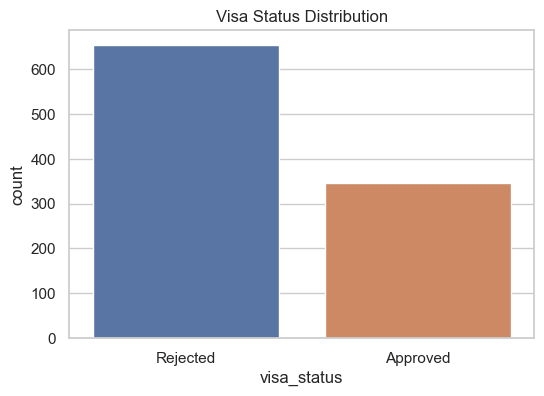

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x="visa_status", data=df)
plt.title("Visa Status Distribution")
plt.show()

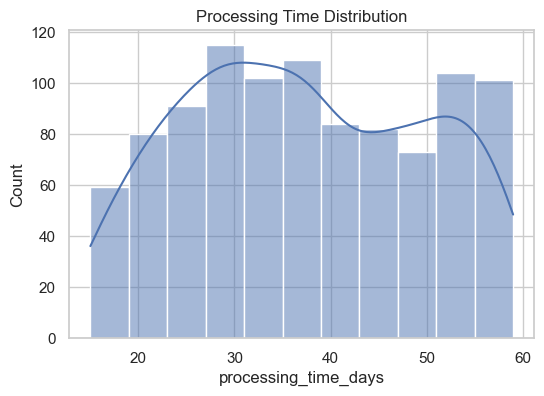

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df["processing_time_days"], kde=True)
plt.title("Processing Time Distribution")
plt.show()

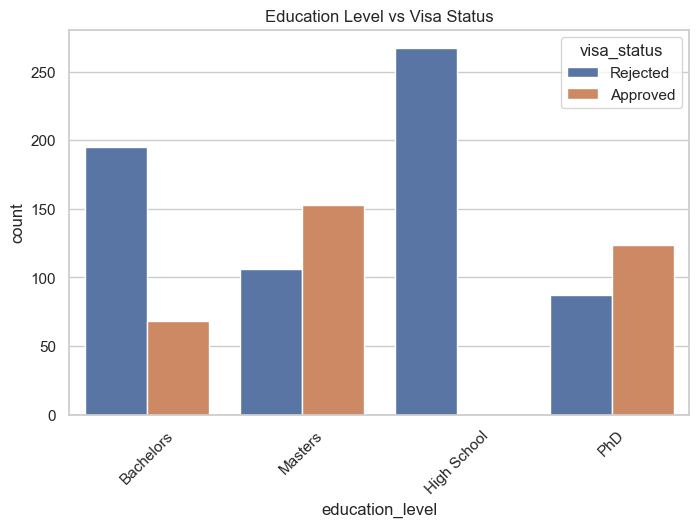

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="education_level", hue="visa_status", data=df)
plt.xticks(rotation=45)
plt.title("Education Level vs Visa Status")
plt.show()

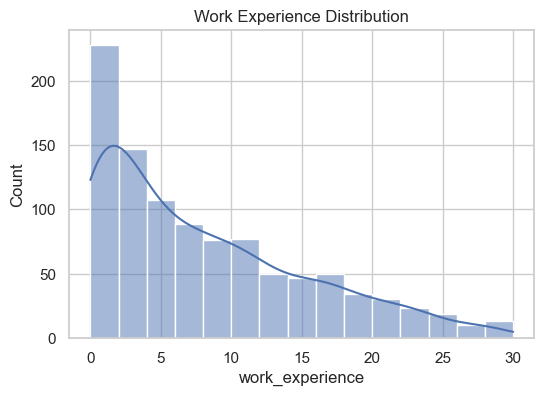

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df["work_experience"], kde=True)
plt.title("Work Experience Distribution")
plt.show()

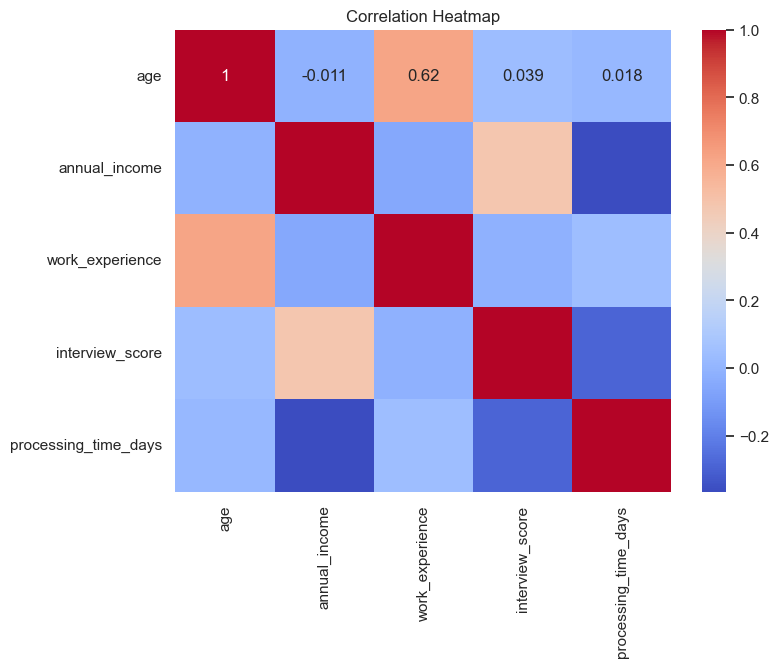

In [41]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [42]:
df["documents_complete"] = df["documents_complete"].map({"Yes":1, "No":0})
df["previous_visa_rejection"] = df["previous_visa_rejection"].map({"Yes":1, "No":0})
df["visa_status"] = df["visa_status"].map({"Approved":1, "Rejected":0})

In [43]:
df["experience_level"] = df["work_experience"].apply(
    lambda x: "Fresher" if x < 3 else "Experienced"
)

print(df.head())

   age  annual_income education_level  work_experience visa_type    country  \
0   24          27869       Bachelors                0   Tourist    Germany   
1   37          34357         Masters               12      Work     Canada   
2   46           6363     High School               25   Tourist  Australia   
3   32          14523     High School                6   Tourist     Canada   
4   28           7292     High School                9   Student        USA   

   documents_complete  interview_score  previous_visa_rejection  \
0                   0                6                        0   
1                   1                8                        0   
2                   1                3                        1   
3                   0                5                        0   
4                   1                5                        0   

   processing_time_days  visa_status experience_level  
0                    52            0          Fresher  
1         

In [44]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("\nEncoded Data Preview:")
print(df_encoded.head())


Encoded Data Preview:
   age  annual_income  work_experience  documents_complete  interview_score  \
0   24          27869                0                   0                6   
1   37          34357               12                   1                8   
2   46           6363               25                   1                3   
3   32          14523                6                   0                5   
4   28           7292                9                   1                5   

   previous_visa_rejection  processing_time_days  visa_status  \
0                        0                    52            0   
1                        0                    34            1   
2                        1                    45            0   
3                        0                    56            0   
4                        0                    37            0   

   education_level_High School  education_level_Masters  education_level_PhD  \
0                        False 